In [2]:
import pandas as pd
import numpy as np
import lightgbm as lgb
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error

train = pd.read_csv('./data/train.csv')
test = pd.read_csv('./data/test.csv')

print(f"학습 데이터 크기: {train.shape}")
print(f"테스트 데이터 크기: {test.shape}")

TARGET = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

# feature_cols = [c for c in train.columns if c not in ID_COLS + [TARGET]]
# print(f"피처 수: {len(feature_cols)}")

# kf = KFold(n_splits=5, shuffle=True, random_state=42)
# oof_preds = np.zeros(len(train))
# test_preds = np.zeros(len(test))

# for fold, (tr_idx, val_idx) in enumerate(kf.split(train)):
#     print(f"── Fold {fold + 1} ──")
#     X_tr = train.loc[tr_idx, feature_cols]
#     y_tr = train.loc[tr_idx, TARGET]
#     X_val = train.loc[val_idx, feature_cols]
#     y_val = train.loc[val_idx, TARGET]

#     model = LGBMRegressor(
#         n_estimators=1000, learning_rate=0.05, max_depth=7,
#         num_leaves=63, subsample=0.8, colsample_bytree=0.8,
#         reg_alpha=0.1, reg_lambda=0.1, random_state=42, verbose=-1,
#     )
#     model.fit(
#         X_tr, y_tr,
#         eval_set=[(X_val, y_val)],
#         callbacks=[lgb.early_stopping(50), lgb.log_evaluation(100)],
#     )

#     oof_preds[val_idx] = model.predict(X_val)
#     test_preds += model.predict(test[feature_cols]) / 5

# oof_mae = mean_absolute_error(train[TARGET], oof_preds)
# print(f"OOF MAE: {oof_mae:.4f}")

학습 데이터 크기: (250000, 94)
테스트 데이터 크기: (50000, 93)


In [7]:
train.describe()

,order_inflow_15m,unique_sku_15m,avg_items_per_order,urgent_order_ratio,heavy_item_ratio,cold_chain_ratio,sku_concentration,robot_active,robot_idle,robot_charging,...,racking_height_avg_m,cross_dock_ratio,packaging_material_cost,quality_check_rate,outbound_truck_wait_min,dock_to_stock_hours,kpi_otd_pct,backorder_ratio,shift_handover_delay_min,sort_accuracy_pct
count,220436.000000,220076.000000,220377.000000,220246.000000,220384.000000,220549.000000,220301.000000,250000.000000,250000.000000,250000.000000,...,220358.000000,220457.000000,220273.000000,220448.000000,220544.000000,220532.000000,220595.000000,220448.000000,220466.000000,220230.000000
mean,94.585662,108.275673,3.473318,0.112411,0.179021,0.094962,0.425110,13.379388,25.813408,6.128704,...,6.895087,0.214840,4.927512,0.126086,14.018698,9.291452,87.077735,0.092604,5.005130,96.429794
std,77.083546,105.558290,2.190259,0.108145,0.111210,0.081449,0.192997,11.449100,22.687023,12.433735,...,2.246697,0.106773,2.213228,0.059362,7.103918,4.791728,6.328054,0.041663,3.034295,2.127183
min,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.100000,0.000000,0.000000,0.000000,...,2.000000,0.000000,0.500000,0.000000,0.000000,1.000000,70.000000,0.000000,0.000000,90.000000
25%,29.000000,37.000000,1.460000,0.023300,0.100000,0.026000,0.268500,4.000000,2.000000,0.000000,...,5.080000,0.130400,3.260000,0.079200,8.600000,5.430000,82.300000,0.060600,2.510000,94.770000
50%,78.000000,73.000000,2.840000,0.081100,0.176500,0.083300,0.399300,10.000000,23.000000,0.000000,...,6.890000,0.214600,4.910000,0.126300,13.900000,9.300000,87.100000,0.092200,5.020000,96.450000
75%,142.000000,141.000000,4.980000,0.179900,0.254600,0.144400,0.557000,19.000000,45.000000,6.000000,...,8.710000,0.298800,6.450000,0.172700,18.800000,13.080000,91.900000,0.124000,7.470000,98.150000
max,477.000000,500.000000,15.000000,1.000000,1.000000,0.500000,0.900000,79.000000,80.000000,80.000000,...,12.000000,0.500000,10.000000,0.300000,30.000000,24.000000,100.000000,0.200000,15.000000,100.000000


ValueError: could not convert string to float: 'WH_136'

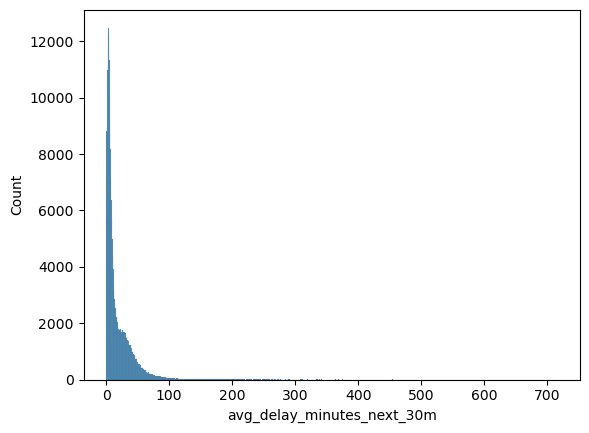

In [10]:
import seaborn as sns

train = train.drop(columns=['ID'])
sns.histplot(train[TARGET])
sns.heatmap(train.corr(), cmap='coolwarm')